# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Aqsa Firdaus
- Email: maqsafirdaus1@gmail.com
- Id Dicoding: CDCC284D6Y0355

## Persiapan

### Menyiapkan library yang dibutuhkan

Pada tahap ini dilakukan import berbagai library yang akan digunakan selama proses analisis data, pembuatan model machine learning, serta evaluasi model. Library yang digunakan meliputi Pandas dan NumPy untuk pengolahan data, Matplotlib dan Seaborn untuk visualisasi, serta Scikit-Learn untuk preprocessing, pembuatan model, dan evaluasi.

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Menyiapkan data yang akan diguankan

Dataset yang digunakan merupakan dataset Students' Performance yang berisi informasi mengenai karakteristik mahasiswa, kondisi sosial ekonomi, serta performa akademik mahasiswa pada semester pertama dan kedua.

Tujuan dari analisis ini adalah membangun model klasifikasi yang mampu memprediksi status akhir mahasiswa, yaitu Dropout, Enrolled, atau Graduate.

In [63]:
df = pd.read_csv('data.csv', sep=';')

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [64]:
df.shape

(4424, 37)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Data Understanding

Tahap Data Understanding dilakukan untuk memahami karakteristik data, jumlah observasi, tipe data, serta distribusi variabel target. Selain itu, dilakukan eksplorasi data menggunakan visualisasi untuk memperoleh insight mengenai faktor-faktor yang dapat memengaruhi kemungkinan mahasiswa mengalami dropout.

### Mengecek Missing Value

Langkah selanjutnya adalah memeriksa keberadaan missing value pada setiap variabel. Missing value dapat memengaruhi performa model sehingga perlu ditangani sebelum proses pemodelan dilakukan.

In [66]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


### Mengecek Data Duplikat

Selain missing value, dilakukan pula pemeriksaan data duplikat untuk memastikan kualitas dataset tetap terjaga.

In [67]:
df.duplicated().sum()

0

### Mapping Kategori Data

Beberapa atribut yang masih direpresentasikan dalam bentuk kode numerik dikonversi menjadi label kategorikal yang lebih mudah dipahami. Mapping dilakukan pada variabel seperti Gender, Debtor, Scholarship Holder dan Tuition Fees Up To Date

In [68]:
# Copy khusus untuk Mapping
df_eda = df.copy()

df_eda['Gender'] = df_eda['Gender'].map({
    0: 'Female',
    1: 'Male'
})

df_eda['Debtor'] = df_eda['Debtor'].map({
    0: 'No',
    1: 'Yes'
})

df_eda['Scholarship_holder'] = df_eda['Scholarship_holder'].map({
    0: 'No',
    1: 'Yes'
})

df_eda['Tuition_fees_up_to_date'] = df_eda['Tuition_fees_up_to_date'].map({
    0: 'No',
    1: 'Yes'
})

### Menampilkan Nilai di Setiap Grafik

Untuk meningkatkan keterbacaan visualisasi, dilakukan penambahan nilai frekuensi pada setiap grafik. Nilai tersebut menunjukkan jumlah data pada masing-masing kategori sehingga informasi dapat diperoleh secara langsung tanpa perlu memperkirakan berdasarkan tinggi batang pada grafik.

In [69]:
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2,
             p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

### Distribusi Target

Visualisasi berikut menunjukkan distribusi status mahasiswa pada dataset, yaitu Dropout, Enrolled, dan Graduate.

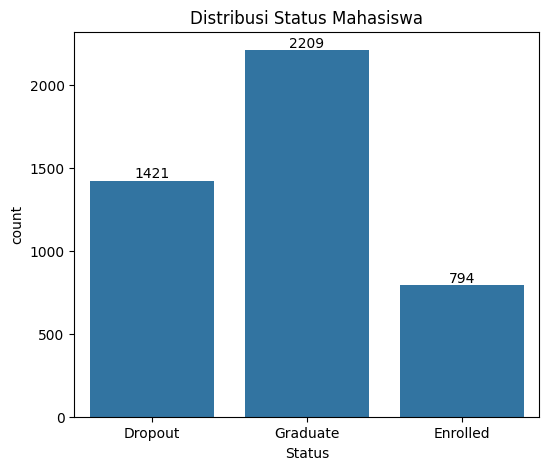

In [70]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df_eda,
    x='Status'
)

add_labels(ax)

plt.title('Distribusi Status Mahasiswa')
plt.show()

### Distribusi Usia Mahasiswa

Visualisasi distribusi usia digunakan untuk mengetahui rentang usia mahasiswa ketika pertama kali mendaftar.

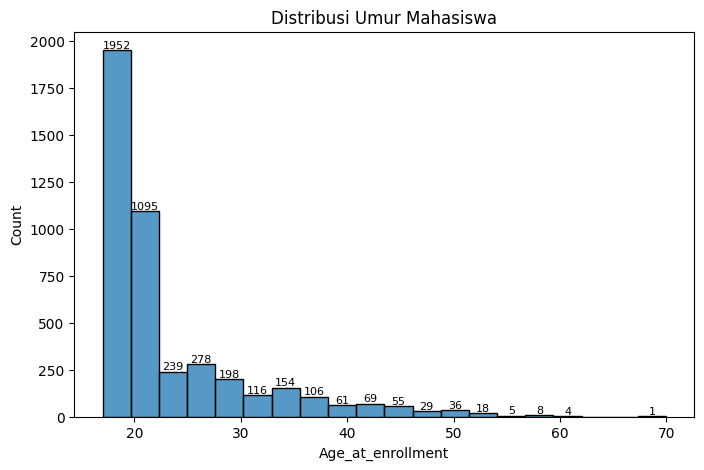

In [71]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    df_eda['Age_at_enrollment'],
    bins=20
)

for p in ax.patches:
    h = p.get_height()

    if h > 0:
        ax.annotate(
            f'{int(h)}',
            (p.get_x() + p.get_width()/2, h),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('Distribusi Umur Mahasiswa')
plt.show()

### Distribusi Gender

Visualisasi berikut menunjukkan proporsi mahasiswa berdasarkan jenis kelamin.

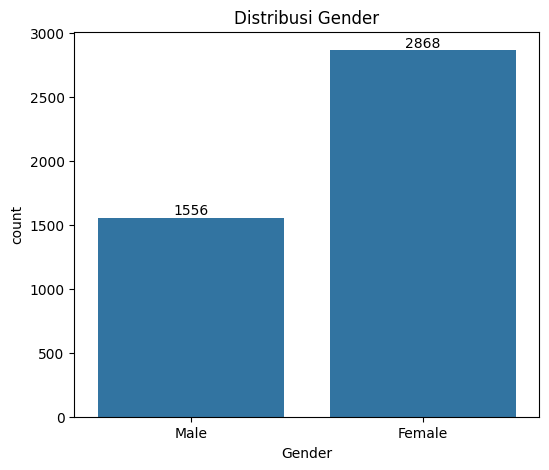

In [72]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df_eda,
    x='Gender'
)

add_labels(ax)

plt.title('Distribusi Gender')
plt.show()

### Status Pembayaran Biaya Kuliah

Status pembayaran biaya kuliah diduga menjadi salah satu faktor yang memengaruhi kemungkinan mahasiswa mengalami dropout.

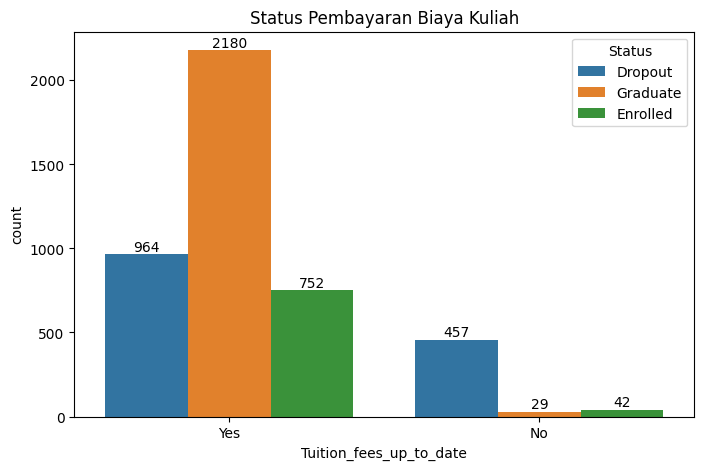

In [73]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_eda,
    x='Tuition_fees_up_to_date',
    hue='Status'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Status Pembayaran Biaya Kuliah')
plt.show()

### Scholarship Holder

Analisis dilakukan untuk mengetahui hubungan antara kepemilikan beasiswa dengan status akhir mahasiswa.

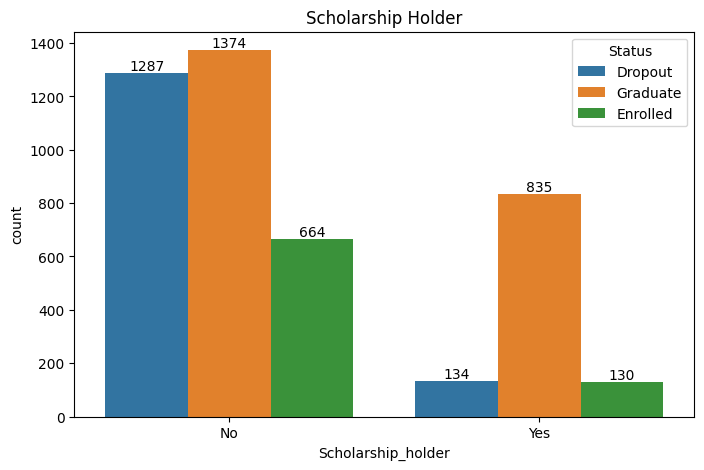

In [74]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_eda,
    x='Scholarship_holder',
    hue='Status'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Scholarship Holder')
plt.show()

### Debtor

Mahasiswa yang memiliki tunggakan pembayaran diduga memiliki risiko dropout yang lebih tinggi dibandingkan mahasiswa yang tidak memiliki tunggakan.

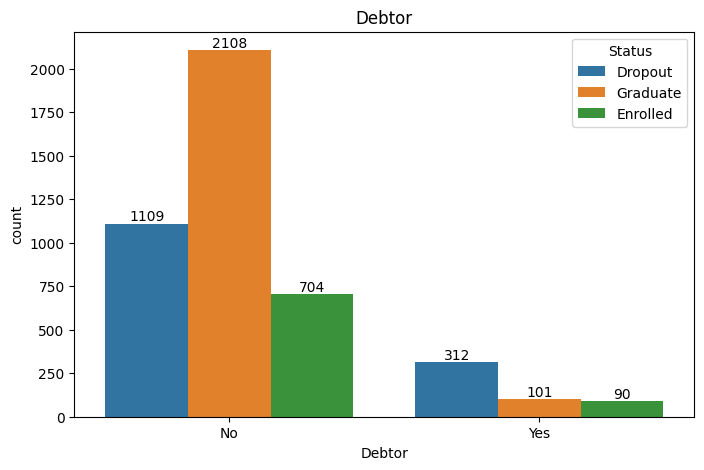

In [75]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_eda,
    x='Debtor',
    hue='Status'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Debtor')
plt.show()

## Insight Data Understanding

- Sebagian besar mahasiswa berada pada kategori Graduate (2.209 mahasiswa), diikuti oleh Dropout (1.421 mahasiswa) dan Enrolled (794 mahasiswa).
- Distribusi umur mahasiswa didominasi oleh rentang usia 18–22 tahun, yang menunjukkan bahwa sebagian besar mahasiswa masuk perguruan tinggi segera setelah menyelesaikan pendidikan menengah. Namun, terdapat beberapa mahasiswa dengan usia yang jauh lebih tinggi sehingga distribusi umur bersifat right-skewed.
- Jumlah mahasiswa perempuan (2.868) lebih banyak dibandingkan mahasiswa laki-laki (1.556)
- Mahasiswa yang membayar biaya kuliah tepat waktu cenderung memiliki status Graduate lebih tinggi dibandingkan mahasiswa yang tidak membayar tepat waktu. Sebaliknya, proporsi mahasiswa Dropout relatif lebih besar pada kelompok yang memiliki tunggakan pembayaran.
- Mahasiswa yang menerima beasiswa menunjukkan jumlah Graduate yang jauh lebih tinggi dibandingkan jumlah Dropout. Hal ini mengindikasikan bahwa dukungan finansial melalui beasiswa berpotensi berkontribusi terhadap keberhasilan studi mahasiswa.
- Sebagian besar mahasiswa tidak memiliki status Debtor (tidak memiliki tunggakan atau kewajiban finansial). Pada kelompok mahasiswa yang berstatus Debtor, jumlah mahasiswa Dropout relatif lebih tinggi dibandingkan kategori status lainnya, yang mengindikasikan adanya hubungan antara kondisi finansial dan risiko putus studi.
- Variabel Tuition Fees Up To Date, Scholarship Holder, dan Debtor menunjukkan pola distribusi yang berbeda untuk setiap status mahasiswa, sehingga berpotensi menjadi fitur penting dalam proses klasifikasi status akademik mahasiswa.

## Data Preparation / Preprocessing

Tahap ini dilakukan untuk mempersiapkan data sebelum digunakan pada proses pelatihan model. Proses yang dilakukan meliputi pemisahan fitur dan target, pembagian data latih dan data uji, serta normalisasi data menggunakan StandardScaler.

### Filter Kolom Status

Membuat filter untuk kolom status dengan mengambil status graduate dan dropout saja

In [76]:
df = df[
    df['Status'].isin(['Dropout', 'Graduate'])
].copy()

### Memisahkan Fitur dan Target

In [77]:
X = df.drop(columns=['Status'])
y = df['Status']

### Train Test Split

Data dibagi menjadi data latih dan data uji dengan perbandingan 80:20.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

Normalisasi data dilakukan menggunakan StandardScaler untuk menyamakan skala antar fitur sehingga proses pelatihan model dapat berjalan lebih optimal.

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

Pada tahap ini dilakukan pembangunan beberapa model machine learning untuk memprediksi status mahasiswa. Model yang digunakan adalah Logistic Regression, Decision Tree, dan Random Forest. Selanjutnya performa setiap model akan dibandingkan untuk memperoleh model terbaik.

### Logistic Regression

In [80]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

### Decision Tree

In [81]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Random Forest

In [82]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Evaluation

Tahap evaluasi dilakukan untuk mengetahui kemampuan model dalam memprediksi status mahasiswa. Metode evaluasi yang digunakan meliputi accuracy score, classification report, dan confusion matrix.

### Logistic Regression

In [83]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9146005509641874
              precision    recall  f1-score   support

     Dropout       0.94      0.84      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



### Decision Tree

In [84]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy : 0.8581267217630854
              precision    recall  f1-score   support

     Dropout       0.83      0.81      0.82       284
    Graduate       0.88      0.89      0.88       442

    accuracy                           0.86       726
   macro avg       0.85      0.85      0.85       726
weighted avg       0.86      0.86      0.86       726



### Random Forest

In [85]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9146005509641874
              precision    recall  f1-score   support

     Dropout       0.95      0.82      0.88       284
    Graduate       0.90      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



### Confusion Matrix 

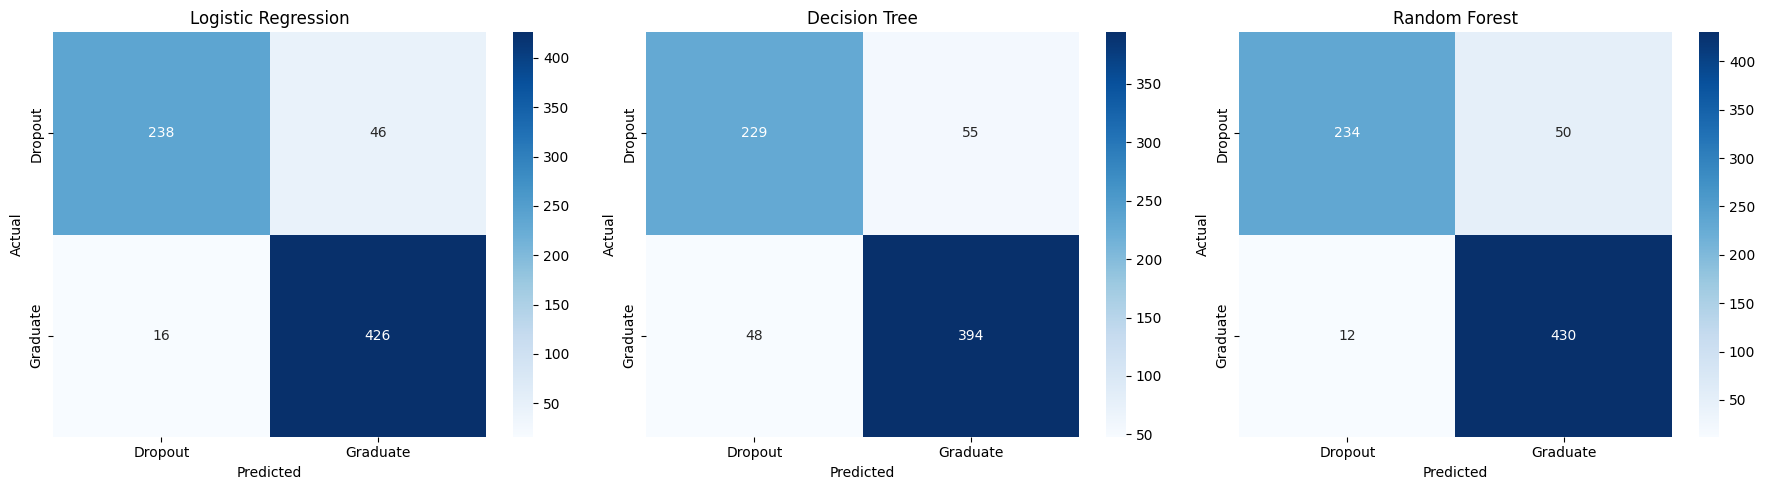

In [90]:
classes = ['Dropout', 'Graduate']

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,5)
)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models):

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Fitur yang Meningkatkan Peluang Dropout

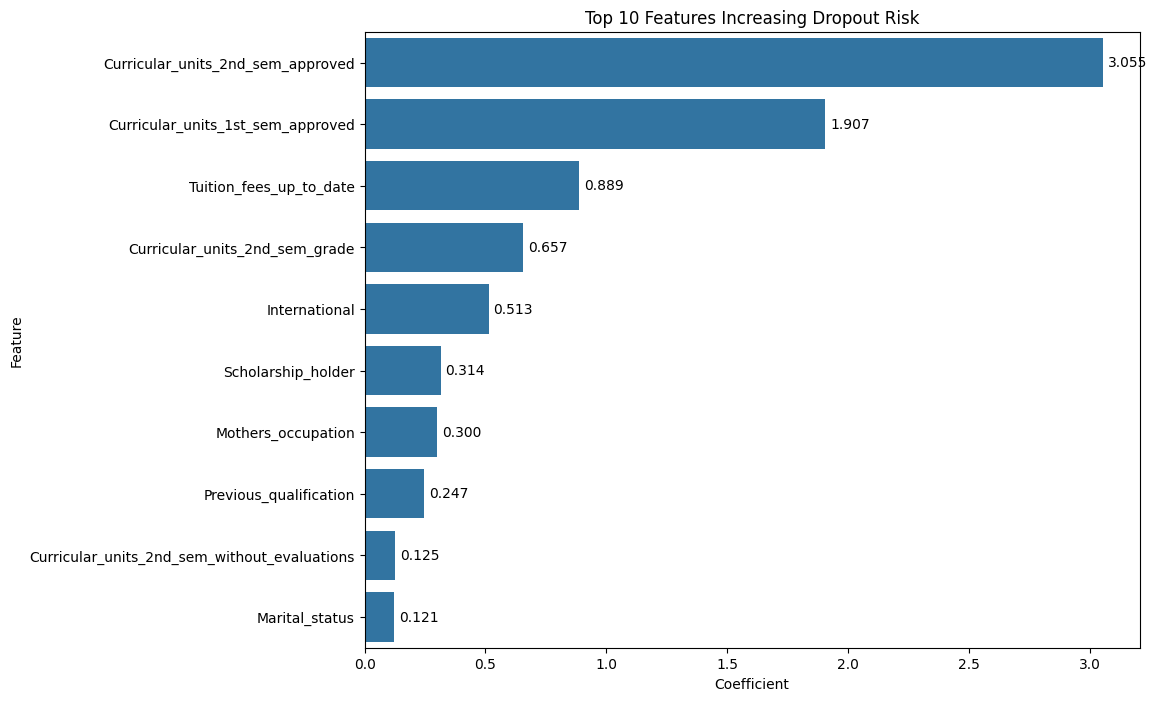

In [88]:
# Koefisien untuk kelas Dropout
dropout_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

# Ambil 10 koefisien positif terbesar
top10_dropout = dropout_coef.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

plt.figure(figsize=(10,8))

ax = sns.barplot(
    data=top10_dropout,
    y='Feature',
    x='Coefficient'
)

# Menampilkan nilai pada bar
for i, v in enumerate(top10_dropout['Coefficient']):
    ax.text(
        v + 0.02,
        i,
        f'{v:.3f}',
        va='center'
    )

plt.title('Top 10 Features Increasing Dropout Risk')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

## Kesimpulan

Berdasarkan hasil evaluasi, Logistic Regression menjadi model terbaik dengan accuracy sebesar 91,46%, lebih tinggi dibandingkan Random Forest dan Decision Tree. Model ini juga mampu mengklasifikasikan kelas Graduate dan Dropout dengan baik, masing-masing memperoleh F1-score sebesar 0,93 dan 0,88.

Analisis fitur menunjukkan bahwa faktor yang paling berpengaruh terhadap risiko dropout adalah Curricular Units 2nd Semester Approved, diikuti oleh Curricular Units 1st Semester Approved, Tuition Fees Up to Date, Curricular Units 2nd Sem Grade, dan International. Selain faktor akademik, faktor seperti Scholarship Holder, Mothers Occupation, Previous Qualification, dan Marital Status juga turut berkontribusi terhadap kemungkinan mahasiswa mengalami dropout.

Secara keseluruhan, hasil analisis menunjukkan bahwa faktor akademik pada tahun pertama dan kedua perkuliahan merupakan indikator utama risiko dropout. Dengan memanfaatkan model Logistic Regression, institusi pendidikan dapat melakukan deteksi dini terhadap mahasiswa yang berisiko dropout sehingga dapat diberikan pendampingan dan intervensi yang lebih tepat sasaran.

## Menyimpan Model

In [89]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, 'model.pkl')

['model.pkl']